In [1]:
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
import pandas as pd
import sqlite3 

In [2]:
con = sqlite3.connect("comp_survey_v5.3.0_10yrs.db")
df = pd.read_sql("select * from observations;", con)
con.close()

In [3]:
bs = [int(note.split(",")[2].split(' ')[-1]) for note in df["scheduler_note"] if "pair_33" in note]

In [4]:
np.unique(bs)

array([35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63])

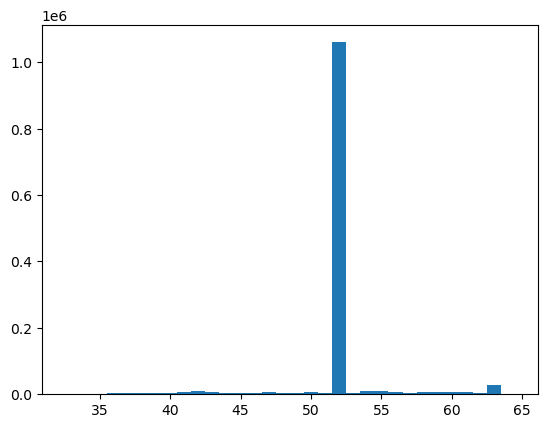

In [5]:
# How do the blob sizes vary? 
_temp = plt.hist(bs, bins=np.arange(33,66)-0.5)


In [6]:
# ok, so 14% of pairs are deviating from the ideal time
np.size(np.where(np.array(bs) != 52)[0])/np.size(bs)

0.13991052064258905

In [7]:
pa = [note for note in df["scheduler_note"] if "pair_33" in note and note[-1] == "a"]
pb = [note for note in df["scheduler_note"] if "pair_33" in note and note[-1] == "b"]

In [8]:
# Are we completing pairs?
np.size(pa), np.size(pb)

(620498, 611518)